# CineSentIA — Proyecto final de PLN

**Caso de estudio:** críticas de cine y series en español  
**Autor:** Miguel Angel Lozada Torrico

## Objetivo

Desarrollar un sistema de Procesamiento de Lenguaje Natural para analizar críticas de cine y series en español, identificando su sentimiento, los temas predominantes y las opiniones relacionadas con aspectos como el guion, la actuación y la dirección.

Se comparan dos enfoques de clasificación: TF-IDF con Multinomial Naive Bayes como modelo clásico y una red BiLSTM con embeddings aprendidos como modelo neuronal.

## 1. Configuración del entorno



In [ ]:
!pip -q install -U gradio python-docx nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.2 MB/s eta 0:00:00


In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import re, gc, json, time, html, random, shutil, warnings, unicodedata
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import nltk

from IPython.display import display
from tqdm.auto import tqdm
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
nltk.download("stopwords", quiet=True)
tqdm.pandas()

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("Acelerador:", gpus[0].name if gpus else "CPU (funcionará, pero más lento)")
print("✓ Entorno preparado")

TensorFlow: 2.20.0
Acelerador: /physical_device:GPU:0
✓ Entorno preparado


## 2. Cargar y validar los datos

Pulsa **Elegir archivos** y selecciona `IMDB Dataset SPANISH.csv`.

In [ ]:
from google.colab import files

NOMBRE = "IMDB Dataset SPANISH.csv"
ruta = Path("/content") / NOMBRE
if not ruta.exists():
    print("Selecciona:", NOMBRE)
    subidos = files.upload()
    csvs = [x for x in subidos if x.lower().endswith(".csv")]
    if not csvs:
        raise FileNotFoundError("No se subió un CSV. Ejecuta de nuevo esta celda.")
    ruta = Path("/content") / (NOMBRE if NOMBRE in csvs else csvs[0])
print("✓ Archivo:", ruta)

Selecciona: IMDB Dataset SPANISH.csv


Saving IMDB Dataset SPANISH.csv to IMDB Dataset SPANISH.csv
✓ Archivo: /content/IMDB Dataset SPANISH.csv


In [ ]:
raw = pd.read_csv(ruta, encoding="utf-8")
requeridas = {"review_es", "sentimiento"}
if not requeridas.issubset(raw.columns):
    raise ValueError(f"Se necesitan {requeridas}. Se encontraron {raw.columns.tolist()}")

df = raw[["review_es", "sentimiento"]].rename(
    columns={"review_es": "texto", "sentimiento": "etiqueta_texto"}
).copy()
df["texto"] = df["texto"].astype("string").str.strip()
df["etiqueta_texto"] = df["etiqueta_texto"].astype("string").str.lower().str.strip()
mapa = {"positivo": 1, "positive": 1, "pos": 1,
        "negativo": 0, "negative": 0, "neg": 0}
df["etiqueta"] = df["etiqueta_texto"].map(mapa)

n0 = len(df)
nulos = int(df[["texto", "etiqueta"]].isna().any(axis=1).sum())
df = df.dropna(subset=["texto", "etiqueta"])
df = df[df.texto.str.len() >= 10]
duplicados = int(df.duplicated("texto").sum())
df = df.drop_duplicates("texto").reset_index(drop=True)
df["etiqueta"] = df["etiqueta"].astype("int8")

resumen_datos = pd.DataFrame({
    "Indicador": ["Filas originales", "Filas válidas", "Nulos eliminados",
                  "Duplicados eliminados", "Positivas", "Negativas"],
    "Valor": [n0, len(df), nulos, duplicados,
              int((df.etiqueta == 1).sum()), int((df.etiqueta == 0).sum())]
})
display(resumen_datos)
display(df.sample(3, random_state=SEED))
assert len(df) >= 1000 and df.etiqueta.nunique() == 2
print("✓ Dataset validado")

,Indicador,Valor
0,Filas originales,50000
1,Filas válidas,49599
2,Nulos eliminados,0
3,Duplicados eliminados,401
4,Positivas,24886
5,Negativas,24713


,texto,etiqueta_texto,etiqueta
33215,"Dos años después del éxito de 'avión', Jim Abr...",positivo,1
6537,"He leído los comentarios de KERCHING ON IMDB, ...",positivo,1
8224,"Una historia sobre el amor y el odio, la trage...",positivo,1


✓ Dataset validado


## 3. Análisis exploratorio

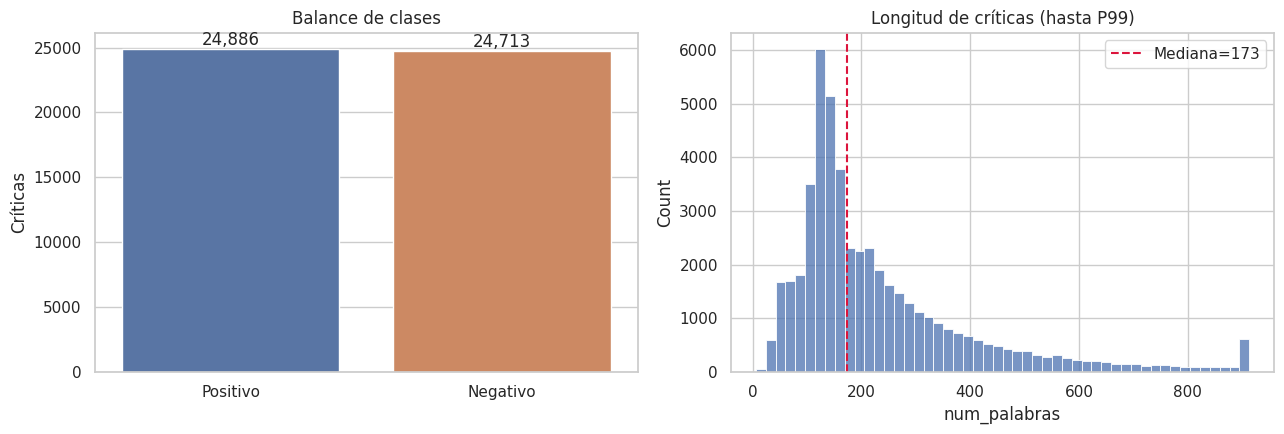

,num_palabras
count,49599.000000
mean,237.436884
std,179.696966
min,6.000000
50%,173.000000
75%,293.000000
90%,474.000000
95%,623.000000
99%,913.000000
max,2450.000000


In [ ]:
df["num_palabras"] = df.texto.str.split().str.len()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
conteo = df.etiqueta.map({0: "Negativo", 1: "Positivo"}).value_counts()
sns.barplot(x=conteo.index, y=conteo.values, hue=conteo.index, legend=False, ax=ax[0])
ax[0].set_title("Balance de clases"); ax[0].set_ylabel("Críticas"); ax[0].set_xlabel("")
for i, v in enumerate(conteo.values): ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

limite = df.num_palabras.quantile(.99)
sns.histplot(df.num_palabras.clip(upper=limite), bins=50, ax=ax[1])
ax[1].axvline(df.num_palabras.median(), color="crimson", ls="--",
              label=f"Mediana={df.num_palabras.median():.0f}")
ax[1].set_title("Longitud de críticas (hasta P99)"); ax[1].legend()
plt.tight_layout(); plt.show()
display(df.num_palabras.describe(percentiles=[.5, .75, .9, .95, .99]).to_frame())

## 4. Pipeline reutilizable

Para TF-IDF/LDA se normaliza y se eliminan palabras vacías, pero se conservan negaciones. Para la BiLSTM la limpieza es ligera, porque el orden y el contexto importan. El stemming queda disponible, pero se desactiva para no deformar expresiones.

In [ ]:
NEGACIONES = {"no", "ni", "nunca", "jamas", "jamás", "sin", "tampoco",
              "nada", "nadie", "ningun", "ningún", "ninguna"}
STOPWORDS_ES = set(stopwords.words("spanish")) - NEGACIONES
STEMMER = SnowballStemmer("spanish")

def limpiar_texto_neuronal(texto: str) -> str:
    texto = html.unescape(str(texto))
    texto = unicodedata.normalize("NFKC", texto)
    texto = re.sub(r"<br\s*/?>", " ", texto, flags=re.I)
    texto = re.sub(r"<[^>]+>", " ", texto)
    texto = re.sub(r"https?://\S+|www\.\S+", " URL ", texto)
    texto = re.sub(r"\S+@\S+", " EMAIL ", texto)
    return re.sub(r"\s+", " ", texto).strip().lower()

def preprocesar_texto(texto: str, quitar_stopwords=True, usar_stemming=False) -> str:
    texto = limpiar_texto_neuronal(texto)
    texto = re.sub(r"\d+", " NUM ", texto)
    tokens = re.findall(r"[a-záéíóúüñ]+", texto, flags=re.I)
    if quitar_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS_ES]
    if usar_stemming:
        tokens = [STEMMER.stem(t) for t in tokens]
    return " ".join(tokens)

ejemplo = "<b>No está nada mal</b>: el guion funciona, pero nunca convence la actuación. 8/10"
print("Original:", ejemplo)
print("Neuronal:", limpiar_texto_neuronal(ejemplo))
print("Clásico:", preprocesar_texto(ejemplo))
assert "no" in preprocesar_texto(ejemplo).split()
assert "nunca" in preprocesar_texto(ejemplo).split()
print("✓ Negaciones conservadas")

Original: <b>No está nada mal</b>: el guion funciona, pero nunca convence la actuación. 8/10
Neuronal: no está nada mal : el guion funciona, pero nunca convence la actuación. 8/10
Clásico: no nada mal guion funciona nunca convence actuación NUM NUM
✓ Negaciones conservadas


In [ ]:
inicio = time.time()
df["texto_neuronal"] = df.texto.progress_apply(limpiar_texto_neuronal)
df["texto_preprocesado"] = df.texto.progress_apply(preprocesar_texto)
vacios = int((df.texto_preprocesado.str.len() == 0).sum())
df = df[df.texto_preprocesado.str.len() > 0].reset_index(drop=True)
print(f"✓ Preprocesamiento: {(time.time()-inicio)/60:.2f} min | vacíos: {vacios}")
display(df[["texto", "texto_preprocesado"]].head(3))

  0%|          | 0/49599 [00:00<?, ?it/s]

  0%|          | 0/49599 [00:00<?, ?it/s]

✓ Preprocesamiento: 0.49 min | vacíos: 0


,texto,texto_preprocesado
0,Uno de los otros críticos ha mencionado que de...,críticos mencionado después ver solo NUM oz ep...
1,Una pequeña pequeña producción.La técnica de f...,pequeña pequeña producción técnica filmación i...
2,Pensé que esta era una manera maravillosa de p...,pensé manera maravillosa pasar tiempo fin sema...


## 5. División sin fuga de información

70% entrenamiento, 15% validación y 15% prueba, estratificados. Ambos modelos usan las mismas filas.

In [ ]:
indices = np.arange(len(df))
idx_train, idx_temp = train_test_split(indices, test_size=.30, random_state=SEED,
                                       stratify=df.etiqueta)
idx_val, idx_test = train_test_split(idx_temp, test_size=.50, random_state=SEED,
                                     stratify=df.loc[idx_temp, "etiqueta"])
y_train = df.loc[idx_train, "etiqueta"].to_numpy()
y_val = df.loc[idx_val, "etiqueta"].to_numpy()
y_test = df.loc[idx_test, "etiqueta"].to_numpy()
particiones = pd.DataFrame({
    "Partición": ["Train", "Validación", "Prueba"],
    "Filas": [len(idx_train), len(idx_val), len(idx_test)],
    "% positivo": [y_train.mean(), y_val.mean(), y_test.mean()]})
display(particiones.style.format({"% positivo": "{:.1%}"}))
assert not set(idx_train) & set(idx_val)
assert not set(idx_train) & set(idx_test)
assert not set(idx_val) & set(idx_test)
print("✓ División correcta")

,Partición,Filas,% positivo
0,Train,34719,50.2%
1,Validación,7440,50.2%
2,Prueba,7440,50.2%


✓ División correcta


## 6. Modelo clásico: TF-IDF + Multinomial Naive Bayes

In [ ]:
X_train_c = df.loc[idx_train, "texto_preprocesado"]
X_val_c = df.loc[idx_val, "texto_preprocesado"]
X_test_c = df.loc[idx_test, "texto_preprocesado"]

modelo_nb = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=40000,
                              min_df=3, max_df=.95, sublinear_tf=True,
                              strip_accents="unicode", dtype=np.float32)),
    ("nb", MultinomialNB(alpha=.5))
])
inicio = time.time(); modelo_nb.fit(X_train_c, y_train); tiempo_nb = time.time()-inicio
prob_val_nb = modelo_nb.predict_proba(X_val_c)[:, 1]
pred_val_nb = (prob_val_nb >= .5).astype(int)
print(f"✓ Naive Bayes entrenado en {tiempo_nb:.1f}s")
print(classification_report(y_val, pred_val_nb,
      target_names=["negativo", "positivo"], digits=4))

✓ Naive Bayes entrenado en 22.2s
              precision    recall  f1-score   support

    negativo     0.8778    0.8546    0.8660      3707
    positivo     0.8593    0.8819    0.8704      3733

    accuracy                         0.8683      7440
   macro avg     0.8686    0.8682    0.8682      7440
weighted avg     0.8685    0.8683    0.8683      7440



In [ ]:
tfidf = modelo_nb.named_steps["tfidf"]
nb_clf = modelo_nb.named_steps["nb"]
vocab = np.array(tfidf.get_feature_names_out())
ratio = nb_clf.feature_log_prob_[1] - nb_clf.feature_log_prob_[0]
terminos_nb = pd.DataFrame({
    "Asociados a positivo": vocab[np.argsort(ratio)[-15:]][::-1],
    "Asociados a negativo": vocab[np.argsort(ratio)[:15]]})
display(terminos_nb)

,Asociados a positivo,Asociados a negativo
0,obligada cualquier,peores peliculas
1,edie,pieza basura
2,primero vi,peor pelicula
3,actuacion increible,peor visto
4,pelicula maravillosa,actuacion horrible
5,trabajo increible,posiblemente peor
6,encantadora pelicula,simplemente malo
7,definitivamente vale,pierdas tiempo
8,encarecidamente pelicula,uwe
9,amo pelicula,perdida tiempo


## 7. Temas con LDA

LDA no usa el sentimiento: descubre grupos de palabras que aparecen juntas. Se ajusta solo con el entrenamiento.

In [ ]:
N_TOPICOS = 8
vectorizador_lda = CountVectorizer(max_features=6000, min_df=10, max_df=.90,
                                   ngram_range=(1, 2), strip_accents="unicode")
inicio = time.time()
X_lda = vectorizador_lda.fit_transform(X_train_c)
modelo_lda = LatentDirichletAllocation(n_components=N_TOPICOS,
    learning_method="online", max_iter=10, batch_size=512,
    random_state=SEED, evaluate_every=-1, n_jobs=-1)
modelo_lda.fit(X_lda); tiempo_lda = time.time()-inicio

def palabras_top(modelo, vectorizador, n=12):
    vocab = np.array(vectorizador.get_feature_names_out())
    filas = []
    for i, comp in enumerate(modelo.components_):
        palabras = vocab[comp.argsort()[-n:][::-1]]
        filas.append({"topico": i, "nombre": f"Tema {i+1}",
                      "palabras": ", ".join(palabras)})
    return pd.DataFrame(filas)

tabla_topicos = palabras_top(modelo_lda, vectorizador_lda)
display(tabla_topicos)
print(f"✓ LDA entrenado en {tiempo_lda/60:.2f} min")

,topico,nombre,palabras
0,0,Tema 1,"num, anos, num num, no, espectaculo, num anos,..."
1,1,Tema 2,"no, pelicula, si, ser, personas, solo, puede, ..."
2,2,Tema 3,"pelicula, historia, peliculas, no, num, sin, g..."
3,3,Tema 4,"pelicula, no, num, si, peliculas, tan, ver, re..."
4,4,Tema 5,"num, pelicula, john, hombre, horror, terror, n..."
5,5,Tema 6,"the, and, of, to, is, in, it, that, this, as, ..."
6,6,Tema 7,"pelicula, gran, comedia, bien, no, ver, mejor,..."
7,7,Tema 8,"no, pelicula, sin, hombre, solo, final, ser, d..."


✓ LDA entrenado en 3.48 min


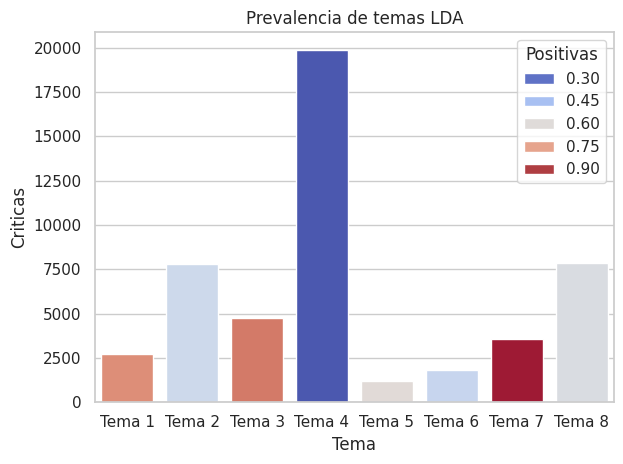

,topico_lda,Criticas,Positivas,Confianza,Tema
0,0,2702,79.0%,46.1%,Tema 1
1,1,7828,54.3%,48.8%,Tema 2
2,2,4746,82.0%,45.7%,Tema 3
3,3,19878,25.7%,61.5%,Tema 4
4,4,1196,60.5%,40.8%,Tema 5
5,5,1815,52.3%,98.9%,Tema 6
6,6,3562,92.4%,46.6%,Tema 7
7,7,7872,57.7%,48.4%,Tema 8


In [ ]:
dist = modelo_lda.transform(vectorizador_lda.transform(df.texto_preprocesado))
df["topico_lda"] = dist.argmax(axis=1)
df["confianza_topico"] = dist.max(axis=1)
resumen_topicos = df.groupby("topico_lda").agg(
    Criticas=("texto", "size"), Positivas=("etiqueta", "mean"),
    Confianza=("confianza_topico", "mean")).reset_index()
resumen_topicos["Tema"] = resumen_topicos.topico_lda.map(lambda x: f"Tema {x+1}")
sns.barplot(data=resumen_topicos, x="Tema", y="Criticas", hue="Positivas",
            palette="coolwarm")
plt.title("Prevalencia de temas LDA"); plt.tight_layout(); plt.show()
display(resumen_topicos.style.format({"Positivas": "{:.1%}", "Confianza": "{:.1%}"}))

## 8. Modelo neuronal: embeddings + BiLSTM

La capa Embedding aprende vectores densos. La BiLSTM usa el orden del texto en ambos sentidos. La parada temprana reduce sobreajuste.

In [ ]:
from tensorflow.keras import layers, callbacks, Model

MAX_TOKENS, LONGITUD, BATCH = 20000, 250, 128
X_train_n = df.loc[idx_train, "texto_neuronal"].astype(str).to_numpy()
X_val_n = df.loc[idx_val, "texto_neuronal"].astype(str).to_numpy()
X_test_n = df.loc[idx_test, "texto_neuronal"].astype(str).to_numpy()

ds_train = (tf.data.Dataset.from_tensor_slices((X_train_n, y_train))
            .shuffle(min(len(X_train_n), 20000), seed=SEED).batch(BATCH)
            .prefetch(tf.data.AUTOTUNE))
ds_val = tf.data.Dataset.from_tensor_slices((X_val_n, y_val)).batch(BATCH).prefetch(tf.data.AUTOTUNE)
ds_test = tf.data.Dataset.from_tensor_slices((X_test_n, y_test)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

vectorizador_nn = layers.TextVectorization(max_tokens=MAX_TOKENS,
    output_mode="int", output_sequence_length=LONGITUD,
    standardize="lower_and_strip_punctuation")
vectorizador_nn.adapt(ds_train.map(lambda texto, etiqueta: texto))

entrada = layers.Input(shape=(), dtype=tf.string, name="critica")
x = vectorizador_nn(entrada)
x = layers.Embedding(MAX_TOKENS, 128, mask_zero=True, name="embedding")(x)
x = layers.SpatialDropout1D(.25)(x)
x = layers.Bidirectional(layers.LSTM(48, dropout=.20), name="bilstm")(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(.35)(x)
salida = layers.Dense(1, activation="sigmoid", name="probabilidad_positiva")(x)
modelo_lstm = Model(entrada, salida, name="CineSentIA_BiLSTM")
modelo_lstm.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy", metrics=["accuracy",
    tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")])
modelo_lstm.summary()

Model: "CineSentIA_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ critica             │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 250)       │          0 │ critica[0][0]     │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 128)  │  2,560,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 250, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 250)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 96)        │     67,968 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      6,208 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ probabilidad_posit… │ (None, 1)         │         65 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,634,241 (10.05 MB)

 Trainable params: 2,634,241 (10.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 5 if gpus else 3
parada = callbacks.EarlyStopping(monitor="val_loss", patience=2,
                                 restore_best_weights=True, verbose=1)
reducir = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=.5,
                                      patience=1, min_lr=1e-5, verbose=1)
inicio = time.time()
historial = modelo_lstm.fit(ds_train, validation_data=ds_val,
    epochs=EPOCHS, callbacks=[parada, reducir], verbose=1)
tiempo_lstm = time.time()-inicio
print(f"✓ BiLSTM entrenada en {tiempo_lstm/60:.2f} min")

Epoch 1/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.7637 - loss: 0.4677 - precision: 0.7571 - recall: 0.7790 - val_accuracy: 0.8626 - val_loss: 0.3259 - val_precision: 0.8670 - val_recall: 0.8578 - learning_rate: 0.0010
Epoch 2/5
272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8987 - loss: 0.2563 - precision: 0.8941 - recall: 0.9051
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
272/272 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.8967 - loss: 0.2611 - precision: 0.8953 - recall: 0.8993 - val_accuracy: 0.8565 - val_loss: 0.3430 - val_precision: 0.8965 - val_recall: 0.8071 - learning_rate: 0.0010
Epoch 3/5
271/272 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9422 - loss: 0.1571 - precision: 0.9442 - recall: 0.9400
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
272/272 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9445 - loss: 0.1520 - precision: 0.9451 - recall: 0.9442 - val_accuracy: 0.8599 - val

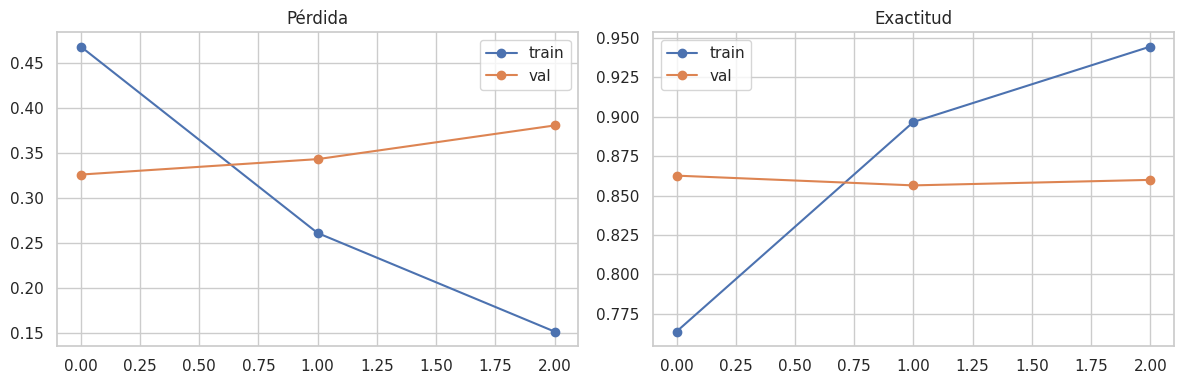

In [ ]:
h = pd.DataFrame(historial.history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h.loss, marker="o", label="train"); ax[0].plot(h.val_loss, marker="o", label="val")
ax[0].set_title("Pérdida"); ax[0].legend()
ax[1].plot(h.accuracy, marker="o", label="train"); ax[1].plot(h.val_accuracy, marker="o", label="val")
ax[1].set_title("Exactitud"); ax[1].legend()
plt.tight_layout(); plt.show()

## 9. Comparación final en prueba

In [ ]:
def medir(nombre, y, prob, tiempo_s):
    pred = (np.asarray(prob) >= .5).astype(int)
    fila = {"Modelo": nombre, "Accuracy": accuracy_score(y, pred),
            "Precision": precision_score(y, pred, zero_division=0),
            "Recall": recall_score(y, pred, zero_division=0),
            "F1": f1_score(y, pred, zero_division=0),
            "ROC_AUC": roc_auc_score(y, prob), "Tiempo_s": tiempo_s}
    return fila, pred

prob_nb = modelo_nb.predict_proba(X_test_c)[:, 1]
prob_lstm = modelo_lstm.predict(ds_test, verbose=1).ravel()
met_nb, pred_nb = medir("TF-IDF + Naive Bayes", y_test, prob_nb, tiempo_nb)
met_lstm, pred_lstm = medir("Embeddings + BiLSTM", y_test, prob_lstm, tiempo_lstm)
metricas = pd.DataFrame([met_nb, met_lstm]).sort_values("F1", ascending=False).reset_index(drop=True)
display(metricas.style.format({c: "{:.4f}" for c in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]})
        .highlight_max(subset=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"], color="#b7e4c7"))
MEJOR_MODELO = metricas.iloc[0].Modelo
print("Modelo para la interfaz:", MEJOR_MODELO)

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC,Tiempo_s
0,TF-IDF + Naive Bayes,0.8704,0.8610,0.8845,0.8726,0.9420,22.206800
1,Embeddings + BiLSTM,0.8616,0.8624,0.8615,0.8620,0.9357,38.497703


Modelo para la interfaz: TF-IDF + Naive Bayes


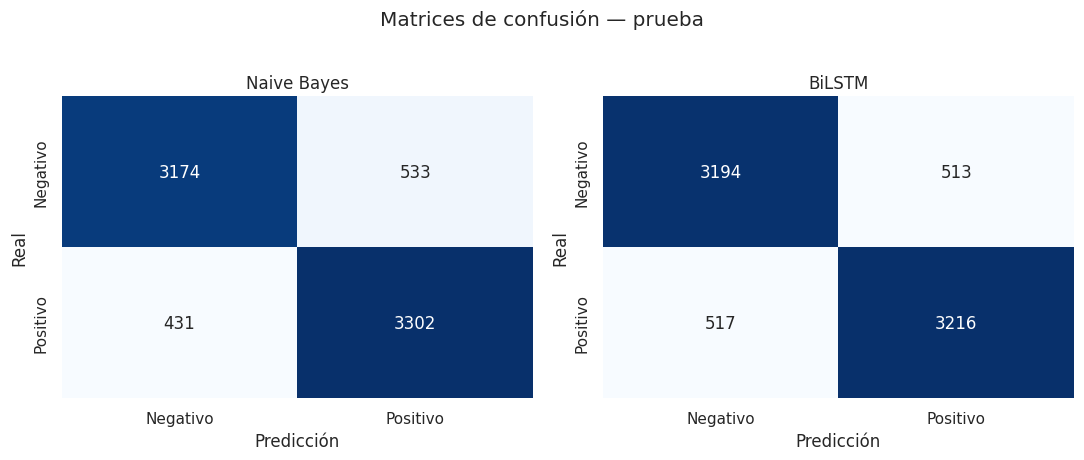

NAIVE BAYES
               precision    recall  f1-score   support

    negativo     0.8804    0.8562    0.8682      3707
    positivo     0.8610    0.8845    0.8726      3733

    accuracy                         0.8704      7440
   macro avg     0.8707    0.8704    0.8704      7440
weighted avg     0.8707    0.8704    0.8704      7440

BiLSTM
               precision    recall  f1-score   support

    negativo     0.8607    0.8616    0.8611      3707
    positivo     0.8624    0.8615    0.8620      3733

    accuracy                         0.8616      7440
   macro avg     0.8616    0.8616    0.8616      7440
weighted avg     0.8616    0.8616    0.8616      7440



In [ ]:
OUT = Path("/content/CineSentIA_entrega")
FIG = OUT / "figuras"; MOD = OUT / "modelos"
FIG.mkdir(parents=True, exist_ok=True); MOD.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for eje, nombre, pred in zip(ax, ["Naive Bayes", "BiLSTM"], [pred_nb, pred_lstm]):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues",
                cbar=False, ax=eje, xticklabels=["Negativo", "Positivo"],
                yticklabels=["Negativo", "Positivo"])
    eje.set_title(nombre); eje.set_xlabel("Predicción"); eje.set_ylabel("Real")
plt.suptitle("Matrices de confusión — prueba", y=1.02)
plt.tight_layout(); plt.savefig(FIG / "matrices_confusion.png", dpi=180, bbox_inches="tight"); plt.show()

print("NAIVE BAYES\n", classification_report(y_test, pred_nb,
      target_names=["negativo", "positivo"], digits=4))
print("BiLSTM\n", classification_report(y_test, pred_lstm,
      target_names=["negativo", "positivo"], digits=4))

## 10. Casos difíciles y errores

Se muestran errores reales y se prueban negación, contraste e ironía. La ironía se declara como limitación porque requiere contexto pragmático.

In [ ]:
pred_mejor = pred_lstm if MEJOR_MODELO == "Embeddings + BiLSTM" else pred_nb
prob_mejor = prob_lstm if MEJOR_MODELO == "Embeddings + BiLSTM" else prob_nb
errores = df.loc[idx_test, ["texto", "etiqueta"]].copy()
errores["prediccion"] = pred_mejor; errores["prob_positiva"] = prob_mejor
errores = errores[errores.etiqueta != errores.prediccion]
print("Errores:", len(errores), "de", len(idx_test))
display(errores.sort_values("prob_positiva").head(3))
display(errores.sort_values("prob_positiva", ascending=False).head(3))

Errores: 964 de 7440


,texto,etiqueta,prediccion,prob_positiva
39449,"Hombre, si alguien esperaba una gran película ...",1,0,0.006350
25062,Esta película es un ejemplo de esterlina del e...,1,0,0.032381
42424,"Encontré este cambio en un videostore, costó $...",1,0,0.057889


,texto,etiqueta,prediccion,prob_positiva
7406,La película fue un placer ver si eres un fanát...,0,1,0.946271
44945,es una buena pelicula.Me encanta la serie en l...,0,1,0.933192
17224,Hollywood Hotel fue la última película musical...,0,1,0.932036


## 11. Recomendación, tema y aspectos

Los aspectos se identifican con un léxico auditable y el mejor clasificador evalúa las oraciones donde aparecen. Es una extensión híbrida, no un modelo ABSA supervisado.

In [ ]:
ASPECTOS = {
 "Guion / historia": ["guion", "historia", "trama", "argumento", "narrativa", "dialogo", "final"],
 "Actuación": ["actuacion", "actor", "actriz", "reparto", "interpretacion"],
 "Dirección": ["direccion", "director", "directora", "realizacion"],
 "Ritmo / duración": ["ritmo", "lenta", "lento", "rapida", "rapido", "duracion", "aburrida", "aburrido"],
 "Música / sonido": ["musica", "banda sonora", "sonido", "audio", "cancion"],
 "Visuales / efectos": ["fotografia", "visual", "efectos", "animacion", "camara"]}

def sin_acentos(t):
    return "".join(c for c in unicodedata.normalize("NFD", str(t))
                   if unicodedata.category(c) != "Mn")

def probabilidad_positiva(textos):
    textos = [str(t) for t in textos]
    if MEJOR_MODELO == "Embeddings + BiLSTM":
        x = np.array([limpiar_texto_neuronal(t) for t in textos], dtype=object)
        return modelo_lstm.predict(x, verbose=0).ravel()
    return modelo_nb.predict_proba([preprocesar_texto(t) for t in textos])[:, 1]

def etiqueta_interfaz(prob, margen=.08):
    if abs(float(prob)-.5) <= margen: return "Neutral / incierto"
    return "Positivo" if prob > .5 else "Negativo"

def predecir_topico(texto):
    x = vectorizador_lda.transform([preprocesar_texto(texto)])
    d = modelo_lda.transform(x)[0]; i = int(d.argmax())
    palabras = tabla_topicos.loc[tabla_topicos.topico == i, "palabras"].iloc[0]
    return i, float(d[i]), palabras

def analizar_aspectos(texto):
    oraciones = [o.strip() for o in re.split(r"(?<=[.!?;])\s+|\n+", str(texto)) if o.strip()]
    filas = []
    for aspecto, claves in ASPECTOS.items():
        evidencias = [o for o in oraciones if any(sin_acentos(c) in sin_acentos(o.lower()) for c in claves)]
        if evidencias:
            p = float(np.mean(probabilidad_positiva(evidencias)))
            filas.append([aspecto, etiqueta_interfaz(p), f"{p:.1%}", evidencias[0][:180]])
        else:
            filas.append([aspecto, "No mencionado", "—", "—"])
    return pd.DataFrame(filas, columns=["Aspecto", "Sentimiento", "Prob. positiva", "Evidencia"])

def analizar_critica(texto):
    if texto is None or len(str(texto).strip()) < 10:
        return "⚠️ Escribe al menos 10 caracteres.", pd.DataFrame(), ""
    p = float(probabilidad_positiva([texto])[0]); sentimiento = etiqueta_interfaz(p)
    recomendacion = ("Sí, recomendada" if sentimiento == "Positivo" else
                     "No recomendada" if sentimiento == "Negativo" else
                     "Opinión mixta; revisar manualmente")
    i, peso, palabras = predecir_topico(texto)
    resumen = (f"### Resultado\n- **Sentimiento:** {sentimiento}\n"
               f"- **Probabilidad positiva:** {p:.1%}\n"
               f"- **Confianza:** {max(p, 1-p):.1%}\n"
               f"- **Recomendación:** {recomendacion}\n"
               f"- **Modelo:** {MEJOR_MODELO}")
    tema = f"### Tema LDA\n**Tema {i+1}** — peso {peso:.1%}\n\nPalabras: {palabras}"
    return resumen, analizar_aspectos(texto), tema

casos = [
 "No está nada mal: la historia tarda en arrancar, pero el final es brillante y la actuación excelente.",
 "La fotografía es preciosa, aunque el guion es predecible y el ritmo resulta insoportablemente lento.",
 "Qué obra maestra: logré dormir durante toda la película."]
display(pd.DataFrame([{"Texto": t, "Sentimiento": etiqueta_interfaz(probabilidad_positiva([t])[0]),
                       "Prob. positiva": probabilidad_positiva([t])[0]} for t in casos]))

,Texto,Sentimiento,Prob. positiva
0,No está nada mal: la historia tarda en arranca...,Positivo,0.580410
1,"La fotografía es preciosa, aunque el guion es ...",Negativo,0.295770
2,Qué obra maestra: logré dormir durante toda la...,Neutral / incierto,0.552003


## 12. Interfaz Gradio

La interfaz desarrollada con Gradio permite ingresar una crítica y obtener el sentimiento general, la probabilidad positiva, la recomendación, el tema LDA predominante y el análisis por aspectos.

In [ ]:
import gradio as gr

with gr.Blocks(title="CineSentIA") as demo:
    gr.Markdown("# 🎬 CineSentIA\nAnálisis de críticas de cine y series en español")
    with gr.Row():
        with gr.Column(scale=2):
            entrada = gr.Textbox(label="Crítica", lines=9,
                placeholder="La actuación fue excelente, pero el guion resultó predecible...")
            boton = gr.Button("Analizar crítica", variant="primary")
        with gr.Column(scale=1):
            resumen = gr.Markdown(); tema = gr.Markdown()
    aspectos = gr.Dataframe(label="Análisis por aspectos", interactive=False, wrap=True)
    gr.Examples([[x] for x in casos], inputs=entrada, label="Casos de demostración")
    boton.click(analizar_critica, entrada, [resumen, aspectos, tema])
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a49f5bb2655ce70cfb.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
